# 🔥 S9 P4 — MLP de régression avec PyTorch Lightning (version Colab)

Régression sur `y = sin(x1) + 0.5·x2² + bruit`, entraînée avec un MLP Lightning.
Même code que sur mon PC, mais prêt à tourner sur un **GPU T4 gratuit** de Google.
Les données sont **synthétiques** (générées dans le notebook) : rien à télécharger.

## Se connecter au T4

**`Select Kernel`** (en haut à droite) → `Select Another Kernel...` → `Colab` →
connexion Google → **`New Colab Server`** → **`GPU`** → **`T4`**

> ⚠️ **Le GPU se choisit à la création du serveur, nulle part ailleurs.**
> `Auto Connect` te donne un CPU. Puis `Run All`.

## 0. Installer les libs manquantes sur Colab

`pytorch_lightning` n'est pas préinstallé sur Colab. On l'installe **seulement** si on
est sur Colab (sur mon PC il est déjà là, la cellule ne fait rien).
`plotly` et `seaborn`, eux, sont déjà fournis par Colab.

In [1]:
try:
    import google.colab
    DANS_COLAB = True
    !pip install -q pytorch_lightning
except ImportError:
    DANS_COLAB = False
    print("Pas sur Colab : rien a installer.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 17.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.3 MB/s eta 0:00:00


## Où je tourne, et sur quoi ?

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("J'execute sur :", "Google Colab (a distance)" if DANS_COLAB else "ton PC")
print(f"torch  : {torch.__version__}")
print(f"device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# Lightning place le modele tout seul via accelerator="auto" : pas de .to(device) a faire.

J'execute sur : Google Colab (a distance)
torch  : 2.11.0+cu128
device : cuda
GPU    : Tesla T4


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

pl.seed_everything(32)


INFO:lightning_fabric.utilities.seed:Seed set to 32


32

In [5]:
# y = sin(x1) + 0.5 * x2 ^2 + noise
n_samples = 1200
rng = np.random.default_rng(32)
x1 = rng.uniform(-3.0, 3.0, size=n_samples)
x2 = rng.uniform(-2.0, 2.0, size=n_samples)
noise = rng.normal(loc=0.0, scale=0.15, size=n_samples)

y = np.sin(x1) +  0.5 * (x2 ** 2) + noise

In [6]:
X = np.column_stack([x1, x2]).astype(np.float32)
y = y.reshape(-1, 1).astype(np.float32)
print(f"X Shape {X.shape} Y Shape {y.shape}")

X Shape (1200, 2) Y Shape (1200, 1)


In [7]:
data = pd.DataFrame({"x1": X[:,0], "x2": X[:,1], "y": y[:,0]})

<Axes: xlabel='x1', ylabel='x2'>

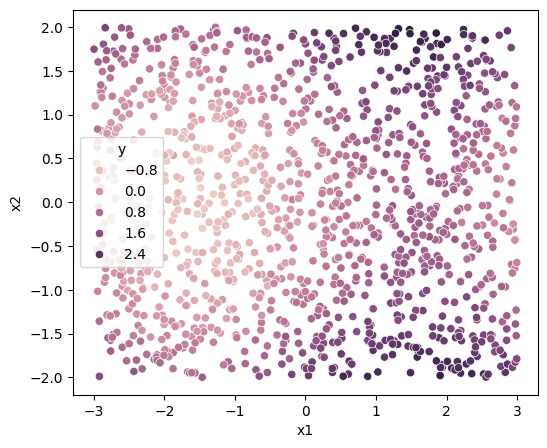

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x="x1", y="x2", hue="y")

In [9]:
import plotly.express as px
fig = plt.figure(figsize=(10,5))
fig = px.scatter_3d(data, x="x1", y="x2", z="y", opacity=0.7)
fig.update_traces(marker_size=2)

<Figure size 1000x500 with 0 Axes>

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples {len(X_train)} Val Samples {len(X_val)}")

Training samples 960 Val Samples 240


In [11]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = x_scaler.fit_transform(X_val).astype(np.float32)

y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
y_val_scaled = y_scaler.fit_transform(y_val).astype(np.float32)

print(f"BEFORE: {X_train.mean()} - {X_train.std()} - {y_train.mean()} - {y_train.std()}")


BEFORE: -0.007744939997792244 - 1.4703361988067627 - 0.6995208859443665 - 0.9720731973648071


In [12]:
print(f"BEFORE: {X_train_scaled.mean()} - {X_train_scaled.std()} - {y_train_scaled.mean()} - {y_train_scaled.std()}")

BEFORE: -3.973643192267673e-09 - 1.0 - -3.973643192267673e-09 - 1.0


In [13]:
x_scaler

StandardScaler()

In [14]:
import plotly.express as px
fig = plt.figure(figsize=(10,5))
data_scaled = pd.DataFrame({"x1": X_train_scaled[:,0], "x2": X_train_scaled[:,1], "y": y_train_scaled[:,0]})
fig = px.scatter_3d(data, x="x1", y="x2", z="y", opacity=0.7)
fig.update_traces(marker_size=2)

<Figure size 1000x500 with 0 Axes>

In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

In [16]:
print(y_train_tensor.shape)

torch.Size([960, 1])


In [17]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        x = self.X[index, :]
        y = self.y[index]
        return x, y

In [18]:
train_dataset = RegressionDataset(X_train_tensor, y_train_tensor)
val_dataset = RegressionDataset(X_val_tensor, y_val_tensor)

In [19]:
len(val_dataset)

240

In [20]:
val_dataset[10]

(tensor([1.1953, 0.5955]), tensor([0.3945]))

In [21]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [22]:
first_batch_x, first_batch_y = next(iter(train_loader))

In [23]:
print(first_batch_x.shape, first_batch_y.shape)

torch.Size([32, 2]) torch.Size([32, 1])


In [24]:
print(first_batch_x, first_batch_y)

tensor([[-1.6587,  1.4391],
        [ 0.2032, -1.5935],
        [-1.2833, -0.3008],
        [ 1.6376, -1.2050],
        [-1.2578, -0.7943],
        [ 1.4543,  0.7857],
        [-0.3310, -0.7825],
        [-0.4872,  1.5247],
        [ 0.5830,  1.5846],
        [-1.4687, -1.3504],
        [ 0.3942,  1.7502],
        [ 0.8931, -0.3552],
        [-0.6953,  1.3467],
        [ 0.6331, -0.6920],
        [ 0.1304, -1.0093],
        [-0.9267, -1.6375],
        [-1.0674, -0.0341],
        [-1.0620, -1.3861],
        [-1.7278, -0.8349],
        [ 1.6438,  1.7243],
        [-0.0817, -1.2306],
        [ 1.2812,  1.2477],
        [ 0.9191,  0.0053],
        [-0.9989, -0.8526],
        [ 1.7032,  1.1855],
        [ 1.5428, -1.3634],
        [-0.8655, -0.4549],
        [ 0.7223,  1.7001],
        [-1.4813, -0.8262],
        [-1.1748, -1.4095],
        [-0.3021, -0.6673],
        [ 1.0490, -0.3293]]) tensor([[ 0.3592],
        [ 1.5767],
        [-1.4962],
        [ 0.8267],
        [-1.4082],
        

In [25]:
class MLPRegressor(pl.LightningModule):
    def __init__(self, input_dim=2, hidden_dim=32, learning_rate=0.01):
        super().__init__()
        self.save_hyperparameters()

        self.model = nn.Sequential(nn.Linear(input_dim, hidden_dim), 
                                   nn.ReLU(), 
                                   nn.Linear(hidden_dim, hidden_dim),
                                   nn.ReLU(),
                                   nn.Linear(hidden_dim, 1))
        
        self.loss_fn = nn.MSELoss()
        self.learning_rate = learning_rate

    def forward(self, x):
            return self.model(x)
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        predictions = self(x)
        loss = self.loss_fn(predictions, y)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        predictions = self(x)
        loss = self.loss_fn(predictions, y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
    
    
    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        return optimizer
        

In [26]:
model = MLPRegressor(input_dim=2, hidden_dim=32, learning_rate=1e-3)

In [27]:
logger = CSVLogger(save_dir="lightning_logs", name="basic_mlp_regressor")

In [28]:
trainer = pl.Trainer(max_epochs=1000,
                    accelerator="auto", 
                    devices="auto", 
                    logger=logger, 
                    enable_checkpointing=False,
                    log_every_n_steps=5)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=train_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential │  1.2 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 K                                                                                                
Total estimated model params size (MB): 0.005                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: 
PossibleUserWarning:

Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for 
val/test dataloaders.

In [ ]:
metrics = pd.read_csv("lightning_logs/basic_mlp_regressor/version_0/metrics.csv")

In [ ]:
metrics
train_loss = metrics.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].last()
val_loss = metrics.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].last()

In [ ]:
px.line(pd.DataFrame({"train": train_loss, "val": val_loss}))